# Curated 

**Rigorous QA**

What get's done:
- Valid mask: Only pixels where both bands > 0 are processed
- Cloud mask validation / refinement
- Atmospheric correction QA
- Co-registration checks
- Outlier removal
- Edge artifacts handling
- NBR calculation only in Vegetated area
- Bright surfaces removal

Sentinel-2 L2A bands are scaled surface reflectanc (x10000) store as integers, not raw DN

Our study area has mixed land cover (vegetation + bare ground + urban)

Precision (false positive reduction) matters more than recall (false negative reduction)


In [1]:
import os
import numpy as np
import numpy.ma as ma
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, to_rgba
import matplotlib.cm as cm
from scipy.ndimage import binary_dilation, binary_fill_holes, binary_closing, binary_erosion, binary_opening, label
import rasterio
from rasterio.mask import mask
from rasterio.features import shapes
from rasterio.features import rasterize
from rasterio import features
import warnings
import geopandas as gpd
from shapely.geometry import shape, MultiPolygon
from shapely.ops import unary_union

In [2]:
# ─── 1. Directorios ────────────────────────────────────────
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR = os.path.join(BASE_DIR, 'data')
OUTPUT_DIR = os.path.join(BASE_DIR, r'output\with_qa')
os.makedirs(OUTPUT_DIR, exist_ok=True)

DATA_PREFIRE_DIR = os.path.join(DATA_DIR, 'prefire')
DATA_POSTFIRE_DIR = os.path.join(DATA_DIR, 'postfire')
OUT_PREFIRE_DIR = os.path.join(OUTPUT_DIR, 'prefire')
OUT_POSTFIRE_DIR = os.path.join(OUTPUT_DIR, 'postfire')

AOI_PATH = os.path.join(DATA_DIR, 'aoi.geojson')
LANDUSE_PATH = os.path.join(DATA_DIR, 'landuse_aoi.geojson')
FIRE_PATH = os.path.join(DATA_DIR, 'true_perimeter.geojson')

# ─── 2. Rutas corregidas (ejemplo 2025-08-01 y 2025-08-23) ───

clip_pre = {
    'B04': os.path.join(DATA_PREFIRE_DIR, 'clip_red.tiff'),
    'B8A': os.path.join(DATA_PREFIRE_DIR, 'clip_nir.tiff'),
    'B12': os.path.join(DATA_PREFIRE_DIR, 'clip_swir2.tiff'),
    'SCL': os.path.join(DATA_PREFIRE_DIR, 'clip_scl.tiff'),
    'AOT': os.path.join(DATA_PREFIRE_DIR, 'clip_aot.tiff'),
    'WVP': os.path.join(DATA_PREFIRE_DIR, 'clip_wvp.tiff')
}

clip_post = {
    'B04': os.path.join(DATA_POSTFIRE_DIR, 'clip_red.tiff'),
    'B8A': os.path.join(DATA_POSTFIRE_DIR, 'clip_nir.tiff'),
    'B12': os.path.join(DATA_POSTFIRE_DIR, 'clip_swir2.tiff'),
    'SCL': os.path.join(DATA_POSTFIRE_DIR, 'clip_scl.tiff'),
    'AOT': os.path.join(DATA_POSTFIRE_DIR, 'clip_aot.tiff'),
    'WVP': os.path.join(DATA_POSTFIRE_DIR, 'clip_wvo.tiff')
}

# 3. Masks

CLOUD_PRE = os.path.join(OUT_PREFIRE_DIR, 'cloud_pre.tif')
CLOUD_POST = os.path.join(OUT_POSTFIRE_DIR, 'cloud_post.tif')

SMOKE_PRE = os.path.join(OUT_PREFIRE_DIR, 'smoke_pre.tif')
SMOKE_POST = os.path.join(OUT_POSTFIRE_DIR, 'smoke_post.tif')

SAT_PRE = os.path.join(OUT_PREFIRE_DIR, 'saturation_pre.tif')
SAT_POST = os.path.join(OUT_POSTFIRE_DIR, 'saturation_post.tif')

OUTLIER_PRE = os.path.join(OUT_PREFIRE_DIR, 'outlier_pre.tif')
OUTLIER_POST = os.path.join(OUT_POSTFIRE_DIR, 'outlier_post.tif')

EDGE_PRE = os.path.join(OUT_PREFIRE_DIR, 'edge_pre.tif')
EDGE_POST = os.path.join(OUT_POSTFIRE_DIR, 'edge_post.tif')

VEG_PRE = os.path.join(OUT_PREFIRE_DIR, 'veg_pre.tif')
BRIGHT_PRE = os.path.join(OUT_PREFIRE_DIR, 'bright_pre.tif')

OUT_PRE  = os.path.join(OUT_PREFIRE_DIR, 'nir_swir2_clip_prefire_raw.tif')
OUT_POST = os.path.join(OUT_POSTFIRE_DIR, 'nir_swir2_clip_postfire_raw.tif')

NBR_PRE  = os.path.join(OUT_PREFIRE_DIR, 'nbr_pre_with_qa.tif')
NBR_POST = os.path.join(OUT_POSTFIRE_DIR, 'nbr_post_with_qa.tif')

DNBR_PATH = os.path.join(OUTPUT_DIR, 'dnbr.tif')
SEVERITY_PATH = os.path.join(OUTPUT_DIR, 'severity_with_qa.tif')
POLYGON_PATH = os.path.join(OUTPUT_DIR, 'burn_polygons_with_qa.gpkg')


## Masks and atmospheric validation

In [3]:
def cloud_mask(scl_path, out_path):
        """
        Sensor QA:
        Enhanced cloud mask using all clouds
        """
        # SCL values:
        # 8 = Cloud medium probability
        # 9 = Cloud high probability
        # 10 = Thin cirrus
        # 3 = Cloud shadows

        with rasterio.open(scl_path) as src:
                scl = src.read(1)
                meta = src.meta.copy()
         
        # Start with SCL clouds (more conservative )
        cloud_mask = np.isin(scl, [3, 8, 9, 10]).astype(np.uint8)  # # Shadows, medium/high prob, cirrus

        # Buffer clouds (clouds cast shadows, edges uncertain)
        cloud_mask = binary_dilation(cloud_mask, iterations=3)
        
        cloud_fraction = np.sum(cloud_mask) / cloud_mask.size
        print(f"  Cloud fraction: {cloud_fraction:.1%}")

        meta.update({
        "driver": "GTiff",
        "count": 1,
        "dtype": "float32",
        "nodata": -9999.0 #masked/cloud
        })

        with rasterio.open(out_path, "w", **meta) as dst:
                dst.write(cloud_mask, 1)
        
        return cloud_mask

In [4]:
cloud_pre = cloud_mask(
    clip_pre['SCL'], 
    CLOUD_PRE
)

cloud_post = cloud_mask(
    clip_post['SCL'], 
    CLOUD_POST
)

  Cloud fraction: 0.0%
  Cloud fraction: 0.0%


In [5]:
def smoke_mask(b8a_path, b12_path, slc_path, out_path):
        """
        Sensor QA
        Detect smoke (different spectral signature than clouds)
        Critical for post-fire imagery!

        Smoke characteristics:
        - Lower reflectance than clouds in visible
        - Higher reflectance than vegetation in NIR
        - Different texture than clouds
        """
        # Smoke typically has:
        # - Moderate blue reflectance (not as bright as clouds)
        # - Reduced NIR absortion
        # - May be flagged as thin cirrus by SCL
        
        with rasterio.open(b8a_path) as src:
                b8a = src.read(1).astype("float32") / 10000.0
                meta = src.meta.copy()
        
        with rasterio.open(b12_path) as src:
                b12 = src.read(1).astype("float32") / 10000.0

        with rasterio.open(slc_path) as src:
                scl = src.read(1).astype(np.float32)
             
        # Simple smoke index
        smoke_candidate = (
                (b8a > 0.15) &        # must still be bright enough
                (b8a < 0.35) &        # not clouds
                (b12 < 0.2) &         # smoke has low SWIR
                ((b8a - b12) > 0.02)  # weak vegetation-like contrast
        )

        # Cross-chech with SCL thin cirrus (often smoke)
        scl_smoke = (scl == 10)

        smoke_mask = smoke_candidate & scl_smoke

        # Morphological cleaning
        smoke_mask = binary_opening(smoke_mask, iterations=1)

        # Smoke fraction
        smoke_fraction = np.sum(smoke_mask) / smoke_mask.size
        print(f"  Smoke fraction: {smoke_fraction:.1%}")

        meta.update({
        "driver": "GTiff",
        "count": 1,
        "dtype": "float32",
        "nodata": -9999 #masked/smoke
        })

        with rasterio.open(out_path, "w", **meta) as dst:
                dst.write(smoke_mask, 1)

        return smoke_mask

In [6]:
smoke_pre = smoke_mask(
    clip_pre['B8A'],
    clip_pre['B12'],
    clip_pre['SCL'], 
    SMOKE_PRE
)

smoke_post = smoke_mask(
    clip_post['B8A'],
    clip_post['B12'],
    clip_post['SCL'], 
    SMOKE_POST
)

  Smoke fraction: 0.0%
  Smoke fraction: 0.0%


In [7]:
def validate_atmospheric_correction(aot_path, wvp_path, b12_path):
    """
    Validate atmospheric correction quality (Sentinel-2 L2A)

    This is NOT QA masking
    It is diagnostic sanity check for:
    - Aerosol loading
    - Water vapor anomalies
    - Overcorrection artifacts

    Returns:
        issues (int): number of detected concerns
    """
    issues = 0

    with rasterio.open(aot_path) as src:
        aot = src.read(1).astype("float32") / 1000.0
    
    if np.any(aot < 0):
        warnings.warn("Negative AOT values detected")
        issues += 1
    
    mean_aot = np.nanmean(aot)

    # Check AOT (Aerosol Optical Thickness)
    if mean_aot is not None:
        if mean_aot > 0.4:
            warnings.warn(f"High aerosol loading (AOT = {mean_aot: .2f})")
            issues += 1
        
    with rasterio.open(wvp_path) as src:
        wvp = src.read(1).astype("float32") / 10000.0

    mean_wvp = np.nanmean(wvp)

    # Check Water Vapor
    if wvp is not None:
        if mean_wvp > 6.0 or mean_wvp < 0:
            warnings.warn(f"Unusual water vapor values (WVP = {mean_wvp: .2f})")
            issues += 1

    # Negative reflectance check (overcorrection)
    with rasterio.open(b12_path) as src:
        b12 = src.read(1).astype("float32") / 10000.0
    
    if np.any(b12 < -0.01):
        warnings.warn("Negative reflectance detected - atmospheric overcorrection")

    return issues
    

In [8]:
aot_pre = validate_atmospheric_correction(
    clip_pre['AOT'],
    clip_pre['WVP'],
    clip_pre['B12']
)

aot_post = validate_atmospheric_correction(
    clip_post['AOT'],
    clip_post['WVP'],
    clip_post['B12']
)

C:\Users\User\AppData\Local\Temp\ipykernel_26936\3958656459.py:20: UserWarning: Negative AOT values detected
  warnings.warn("Negative AOT values detected")
C:\Users\User\AppData\Local\Temp\ipykernel_26936\3958656459.py:47: UserWarning: Negative reflectance detected - atmospheric overcorrection
  warnings.warn("Negative reflectance detected - atmospheric overcorrection")


In [9]:
def saturation_mask(b8a_path, b12_path, out_path, threshold):
    """
    Radiometric QA:
    Check for saturation pixels
    A pixel is saturated if any band exceeds the threshold
    """
    with rasterio.open(b8a_path) as src:
        b8a = src.read(1).astype("float32") / 10000.0 # rescale reflectance before thresholding
        meta = src.meta.copy()
     
    with rasterio.open(b12_path) as src:
        b12 = src.read(1).astype("float32") / 10000.0 # rescale reflectance before thresholding

    sat_mask = (b8a > threshold) | (b12 > threshold)

    # Saturation fraction
    sat_fraction = np.sum(sat_mask) / sat_mask.size
    print(f"  Saturation fraction: {sat_fraction:.1%}")

    #Prepare output array
    sat_mask_out = sat_mask.astype(np.uint8)

    meta.update({
    "driver": "GTiff",
    "count": 1,
    "dtype": "float32",
    "nodata": -9999.0 #masked/saturated
    })

    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(sat_mask_out, 1)

    return sat_mask

In [10]:
sat_pre = saturation_mask(
    clip_pre['B8A'],
    clip_pre['B12'],
    SAT_PRE,
    threshold=0.95
)

sat_post = saturation_mask(
    clip_post['B8A'],
    clip_post['B12'], 
    SAT_POST,
    threshold=0.95
)

  Saturation fraction: 0.0%
  Saturation fraction: 0.0%


In [11]:
def detect_outliers(b8a_path, b12_path, out_path):
    """
    Statistics QA: 
    Detect statistical outliers in key bands

    For Sentinel-2 L2A reflectance:
    True statistical outliers should be extremely rare

    1–2% usually indicates:
    Clouds
    Snow
    Shadows
    Unmasked water
    Or scaling mistakes
    
    This mask is best used as:
    A diagnostic layer
    A sanity check

    Not as a hard QA mask unless carefully validated
    """
    with rasterio.open(b8a_path) as src:
        b8a = src.read(1).astype("float32") / 10000.0 # rescale reflectance before outlier detection
        meta = src.meta.copy()
     
    with rasterio.open(b12_path) as src:
        b12 = src.read(1).astype("float32") / 10000.0 # rescale reflectance before outlier detection

    bands = {
        "B8A": b8a,
        "B12": b12
    }

    outlier_mask = np.zeros(b8a.shape, dtype=bool)


    for name, band in bands.items():
        valid = band[~np.isnan(band)]
        if valid.size == 0:
            continue

        p1, p99 = np.percentile(valid, [1, 99])
        spread = p99 - p1

        # Flag extreme outliers (beyond 3*IQR)
        lower = p1 - 3 * spread
        upper = p99 + 3 * spread

        band_outliers = (band < lower) | (band > upper)

        outlier_mask |= band_outliers

        # Outlier fraction
        outlier_fraction = np.sum(band_outliers) / band_outliers.size
        print(f"  {name} outlier fraction: {outlier_fraction:.1%}")

    total_frac = np.sum(outlier_mask) / outlier_mask.size
    print(f"  Combined outlier fraction: {total_frac:.2%}")

    #Prepare output array
    outlier_mask_out = outlier_mask.astype(np.uint8)

    meta.update({
    "driver": "GTiff",
    "count": 1,
    "dtype": "float32",
    "nodata": -9999 #masked/outlier
    })

    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(outlier_mask_out, 1)

In [12]:
outlier_pre = detect_outliers(
    clip_pre['B8A'],
    clip_pre['B12'],
    OUTLIER_PRE
)

outlier_post = detect_outliers(
    clip_post['B8A'],
    clip_post['B12'], 
    OUTLIER_POST
)

  B8A outlier fraction: 0.0%
  B12 outlier fraction: 0.0%
  Combined outlier fraction: 0.00%
  B8A outlier fraction: 0.0%
  B12 outlier fraction: 0.0%
  Combined outlier fraction: 0.00%


In [13]:
def edge_mask(b8a_path, out_path, buffer_pixels):
    """
    Geometry QA :
    Mask edge pixels (often have artifacts)
    Identifies pixels that are spatially unreliable because they lie near the image boundary

    Purely a geometric mask
    Independent of pixel values
    The same no matter what reflactance values are
    """
    
    with rasterio.open(b8a_path) as src:
        b8a = src.read(1).astype("float32") / 10000.0 # rescale reflectance
        meta = src.meta.copy()

    edge_mask = np.zeros(b8a.shape, dtype=bool)
    edge_mask[:buffer_pixels, :] = True
    edge_mask[-buffer_pixels, :] = True
    edge_mask[:, buffer_pixels] = True
    edge_mask[:, -buffer_pixels] = True

    # Edge fraction
    edge_fraction = np.sum(edge_mask) / edge_mask.size
    print(f"  Edge fraction: {edge_fraction:.1%}")

    #Prepare output array
    edge_mask_out = edge_mask.astype(np.uint8)

    meta.update({
    "driver": "GTiff",
    "count": 1,
    "dtype": "float32",
    "nodata": -9999
    })

    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(edge_mask_out, 1)

    return edge_mask

In [14]:
edge_pre = edge_mask(
    clip_pre['B8A'],
    EDGE_PRE,
    3
)

edge_post = edge_mask(
    clip_post['B8A'],
    EDGE_POST,
    3
)

  Edge fraction: 0.4%
  Edge fraction: 0.4%


In [15]:
def ndvi_mask(b8a_path, b04_path, out_path):
    """
    Vegetation QA:

    Identify where vegetation existed before pre fire to detect where vegetation was destroyed

    Apply only to Prefire-NBR to detect where vegetation was destroyed, not where there never was vegetation
    """

    with rasterio.open(b8a_path) as src:
        b8a = src.read(1).astype("float32") / 10000.0
        meta = src.meta.copy()

    with rasterio.open(b04_path) as src:
        b04 = src.read(1).astype("float32") / 10000.0

    #Define nodata value
    eps = 1e-10

    ndvi = np.zeros_like(b8a)
    ndvi_valid = (b8a + b04) > eps
    ndvi[ndvi_valid] = ((b8a[ndvi_valid] - b04[ndvi_valid]) / \
                        (b8a[ndvi_valid] + b04[ndvi_valid]) )
    
    ndvi_mask = ndvi > 0.25

    # Vegetated fraction
    veg_fraction = np.sum(ndvi_mask) / ndvi_mask.size
    print(f"  Vegetated fraction: {veg_fraction:.1%}")

    #Prepare output array
    ndvi_mask_out = ndvi_mask.astype(np.uint8)

    meta.update({
    "driver": "GTiff",
    "count": 1,
    "dtype": "float32",
    "nodata": -9999
    })

    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(ndvi_mask_out, 1)

    return ndvi_mask

In [16]:
veg_pre = ndvi_mask(
    clip_pre['B8A'],
    clip_pre['B04'],
    VEG_PRE,
)

  Vegetated fraction: 87.2%


In [17]:
def bright_mask(b8a_path, b04_path, b12_path, out_path):
    """
    Brightness QA:

    Exclude bright surfaces such as non-vegetated areas, clouds, snow, bright bare soil, or concrete

    These surfaces are false positives
    """

    with rasterio.open(b8a_path) as src:
        b8a = src.read(1).astype("float32") / 10000.0
        meta = src.meta.copy()

    with rasterio.open(b04_path) as src:
        b04 = src.read(1).astype("float32") / 10000.0

    with rasterio.open(b8a_path) as src:
        b8a = src.read(1).astype("float32") / 10000.0
        meta = src.meta.copy()

    with rasterio.open(b12_path) as src:
        b12 = src.read(1).astype("float32") / 10000.0

    brightness = np.zeros_like(b8a)
    brightness = (b8a + b12 + b04) / 3 
    bright_mask = brightness < 0.40
    
    # Bright fraction
    bright_fraction = np.sum(bright_mask) / bright_mask.size
    print(f"  Bright fraction: {bright_fraction:.1%}")

    #Prepare output array
    bright_mask_out = bright_mask.astype(np.uint8)

    meta.update({
    "driver": "GTiff",
    "count": 1,
    "dtype": "float32",
    "nodata": -9999
    })

    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(bright_mask_out, 1)

    return bright_mask

In [18]:
bright_pre = bright_mask(
    clip_pre['B8A'],
    clip_pre['B04'],
    clip_pre['B12'],
    BRIGHT_PRE,
)

  Bright fraction: 99.9%


## Topographic correction (SCS+C)

Corrects illumination differences caused by terrain slope and aspect.
Applied to B8A and B12 **before** NBR calculation.

Required because A Rúa has extreme relief (valley floor ~300m to peaks >1200m).
Without correction, shaded slopes mimic burn signatures in dNBR.

In [19]:
TERRAIN_PATH = os.path.join(DATA_DIR, 'terrain.tif')


In [20]:
def get_solar_angles(metadata_path):
    """
    Extract mean solar angles from Sentinel-2 MTD_TL.xml metadata.
    
    Returns:
        sun_zenith_deg : float  (degrees)
        sun_azimuth_deg : float (degrees)
    """
    import xml.etree.ElementTree as ET

    tree = ET.parse(metadata_path)
    root = tree.getroot()

    # Navigate to Mean_Sun_Angle
    # Works for both S2A/S2B L2A granule metadata
    for elem in root.iter('Mean_Sun_Angle'):
        zenith = float(elem.find('ZENITH_ANGLE').text)
        azimuth = float(elem.find('AZIMUTH_ANGLE').text)
        return zenith, azimuth

    raise ValueError(f"Mean_Sun_Angle not found in {metadata_path}")


In [22]:
def compute_cos_incidence(slope_deg, aspect_deg, sun_zenith_deg, sun_azimuth_deg):
    """
    Calculate cosine of the solar incidence angle on the terrain surface.
    
    cos(i) = cos(slope) * cos(sun_zenith) 
           + sin(slope) * sin(sun_zenith) * cos(sun_azimuth - aspect)
    
    Parameters:
        slope_deg     : ndarray, slope in degrees
        aspect_deg    : ndarray, aspect in degrees (0-360, clockwise from N)
        sun_zenith_deg  : float, solar zenith angle in degrees
        sun_azimuth_deg : float, solar azimuth angle in degrees
    
    Returns:
        cos_i : ndarray
    """
    slope  = np.radians(slope_deg)
    aspect = np.radians(aspect_deg)
    sz     = np.radians(sun_zenith_deg)
    sa     = np.radians(sun_azimuth_deg)

    cos_i = (
        np.cos(slope) * np.cos(sz)
        + np.sin(slope) * np.sin(sz) * np.cos(sa - aspect)
    )

    return cos_i


In [29]:
from rasterio.warp import reproject, Resampling

def align_terrain_to_band(terrain_path, band_path):
    """
    Reproject and resample terrain (slope, aspect) to match
    the exact grid of a Sentinel-2 band (CRS, resolution, extent).

    Returns:
        slope_aligned  : ndarray (same shape as band)
        aspect_aligned : ndarray (same shape as band)
    """
    with rasterio.open(band_path) as src_band:
        band_crs       = src_band.crs
        band_transform = src_band.transform
        band_width     = src_band.width
        band_height    = src_band.height

    with rasterio.open(terrain_path) as src_t:
        # Read slope (band 2) and aspect (band 3)
        slope_src  = src_t.read(2)
        aspect_src = src_t.read(3)
        terrain_crs = src_t.crs
        terrain_transform = src_t.transform

    # Allocate output arrays
    slope_aligned  = np.empty((band_height, band_width), dtype=np.float32)
    aspect_aligned = np.empty((band_height, band_width), dtype=np.float32)

    # Reproject slope
    reproject(
        source=slope_src,
        destination=slope_aligned,
        src_transform=terrain_transform,
        src_crs=terrain_crs,
        dst_transform=band_transform,
        dst_crs=band_crs,
        resampling=Resampling.bilinear
    )

    # Reproject aspect (use nearest to avoid interpolating angles)
    reproject(
        source=aspect_src,
        destination=aspect_aligned,
        src_transform=terrain_transform,
        src_crs=terrain_crs,
        dst_transform=band_transform,
        dst_crs=band_crs,
        resampling=Resampling.nearest
    )

    print(f"  Terrain aligned: {slope_src.shape} → {slope_aligned.shape}")
    return slope_aligned, aspect_aligned


In [30]:
def scs_c_correction(band_path, terrain_path, sun_zenith_deg, sun_azimuth_deg, out_path):
    """
    SCS+C topographic correction (Soenen et al., 2005).

    Corrects reflectance for terrain-induced illumination differences
    using the Sun-Canopy-Sensor model with empirical C constant.

    Formula:
        ρ_corrected = ρ_observed × (cos(θs) × cos(α) + c) / (cos(i) + c)
    
    where:
        θs    = solar zenith angle
        α     = terrain slope
        cos(i)= cosine of solar incidence angle on terrain
        c     = b/m from linear regression ρ vs cos(i)
    """
    print(f"\nSCS+C correction: {os.path.basename(band_path)}")

    # --- Load reflectance band ---
    with rasterio.open(band_path) as src:
        band = src.read(1).astype("float32")
        meta = src.meta.copy()

    # --- Load terrain aligned to band grid ---
    slope_deg, aspect_deg = align_terrain_to_band(terrain_path, band_path)

    # --- Compute cos(i) ---
    cos_i = compute_cos_incidence(slope_deg, aspect_deg, sun_zenith_deg, sun_azimuth_deg)

    # --- cos(θs) × cos(slope): the SCS numerator term ---
    cos_sz = np.cos(np.radians(sun_zenith_deg))
    slope_rad = np.radians(slope_deg)
    cos_slope = np.cos(slope_rad)
    scs_numerator = cos_sz * cos_slope

    # --- Valid pixels for regression ---
    valid = (
        (band > 0) &
        (cos_i > 0.1) &          # exclude extreme shadow
        (slope_deg > 2.0) &       # flat areas don't need correction
        (aspect_deg >= 0) &       # exclude nodata aspect (-1)
        np.isfinite(band) &
        np.isfinite(cos_i)
    )

    n_valid = np.sum(valid)
    print(f"  Valid pixels for regression: {n_valid} ({n_valid/band.size:.1%})")

    if n_valid < 100:
        print("  ⚠️  Too few valid pixels — skipping correction")
        with rasterio.open(out_path, "w", **meta) as dst:
            dst.write(band, 1)
        return band

    # --- Linear regression: ρ = m × cos(i) + b ---
    if n_valid > 500_000:
        rng = np.random.default_rng(42)
        idx = np.where(valid.ravel())[0]
        sample_idx = rng.choice(idx, 500_000, replace=False)
        cos_i_sample = cos_i.ravel()[sample_idx]
        band_sample = band.ravel()[sample_idx]
    else:
        cos_i_sample = cos_i[valid]
        band_sample = band[valid]

    m, b = np.polyfit(cos_i_sample, band_sample, 1)
    c = b / m if abs(m) > 1e-10 else 0.0

    print(f"  Regression: m={m:.4f}, b={b:.4f}, c={c:.4f}")

    if c < 0:
        print(f"  ⚠️  Negative c={c:.4f} — using |c| as stabilizer")
        c = abs(c)

    # --- Apply SCS+C ---
    corrected = np.copy(band)
    denominator = cos_i + c
    numerator = scs_numerator + c

    apply_mask = valid & (denominator > 0.05)
    corrected[apply_mask] = band[apply_mask] * (numerator[apply_mask] / denominator[apply_mask])

    # --- Clip to reasonable range ---
    corrected = np.clip(corrected, 0, 10000)

    # --- Stats ---
    n_corrected = np.sum(apply_mask)
    mean_before = np.mean(band[apply_mask])
    mean_after = np.mean(corrected[apply_mask])
    print(f"  Corrected pixels: {n_corrected} ({n_corrected/band.size:.1%})")
    print(f"  Mean reflectance: {mean_before:.1f} → {mean_after:.1f}")

    # --- Save ---
    meta.update({"dtype": "float32", "compress": "lzw"})
    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(corrected.astype(np.float32), 1)

    return corrected


In [31]:
# ─── Solar angles from Sentinel-2 granule metadata ───
# Point to the MTD_TL.xml inside each GRANULE folder
# Example: S2B_MSIL2A_.../GRANULE/L2A_.../MTD_TL.xml

META_PRE  = os.path.join(DATA_PREFIRE_DIR, 'MTD_TL.xml')   # adjust path as needed
META_POST = os.path.join(DATA_POSTFIRE_DIR, 'MTD_TL.xml')  # adjust path as needed

# If you already know the angles, you can set them directly:
# sun_zenith_pre, sun_azimuth_pre = 25.3, 152.7
# sun_zenith_post, sun_azimuth_post = 28.1, 158.4

sun_zenith_pre, sun_azimuth_pre = get_solar_angles(META_PRE)
sun_zenith_post, sun_azimuth_post = get_solar_angles(META_POST)

print(f"Pre-fire  solar angles: zenith={sun_zenith_pre:.2f}°, azimuth={sun_azimuth_pre:.2f}°")
print(f"Post-fire solar angles: zenith={sun_zenith_post:.2f}°, azimuth={sun_azimuth_post:.2f}°")


Pre-fire  solar angles: zenith=28.51°, azimuth=146.12°
Post-fire solar angles: zenith=34.28°, azimuth=152.60°


In [32]:
# ─── Output paths for corrected bands ───
TCOR_B8A_PRE  = os.path.join(OUT_PREFIRE_DIR, 'b8a_pre_tcor.tif')
TCOR_B12_PRE  = os.path.join(OUT_PREFIRE_DIR, 'b12_pre_tcor.tif')
TCOR_B8A_POST = os.path.join(OUT_POSTFIRE_DIR, 'b8a_post_tcor.tif')
TCOR_B12_POST = os.path.join(OUT_POSTFIRE_DIR, 'b12_post_tcor.tif')


In [33]:
# ─── Apply SCS+C to pre-fire bands ───
b8a_pre_tcor = scs_c_correction(
    clip_pre['B8A'], TERRAIN_PATH,
    sun_zenith_pre, sun_azimuth_pre,
    TCOR_B8A_PRE
)

b12_pre_tcor = scs_c_correction(
    clip_pre['B12'], TERRAIN_PATH,
    sun_zenith_pre, sun_azimuth_pre,
    TCOR_B12_PRE
)

# ─── Apply SCS+C to post-fire bands ───
b8a_post_tcor = scs_c_correction(
    clip_post['B8A'], TERRAIN_PATH,
    sun_zenith_post, sun_azimuth_post,
    TCOR_B8A_POST
)

b12_post_tcor = scs_c_correction(
    clip_post['B12'], TERRAIN_PATH,
    sun_zenith_post, sun_azimuth_post,
    TCOR_B12_POST
)



SCS+C correction: clip_nir.tiff
  Terrain aligned: (814, 1234) → (1288, 1439)
  Valid pixels for regression: 874341 (47.2%)
  Regression: m=328.0542, b=4025.5997, c=12.2711
  Corrected pixels: 874341 (47.2%)
  Mean reflectance: 4167.1 → 4068.7

SCS+C correction: clip_swir2.tiff
  Terrain aligned: (814, 1234) → (1288, 1439)
  Valid pixels for regression: 874341 (47.2%)
  Regression: m=181.3649, b=1970.2133, c=10.8633
  Corrected pixels: 874341 (47.2%)
  Mean reflectance: 2048.2 → 1995.7

SCS+C correction: clip_nir.tiff
  Terrain aligned: (814, 1234) → (1288, 1439)
  Valid pixels for regression: 858812 (46.3%)
  Regression: m=599.3448, b=2715.2512, c=4.5304
  Corrected pixels: 858812 (46.3%)
  Mean reflectance: 3005.8 → 2791.2

SCS+C correction: clip_swir2.tiff
  Terrain aligned: (814, 1234) → (1288, 1439)
  Valid pixels for regression: 858812 (46.3%)
  Regression: m=21.4779, b=2218.8055, c=103.3064
  Corrected pixels: 858812 (46.3%)
  Mean reflectance: 2229.4 → 2221.7


**Note:** Now pass the corrected band paths (`TCOR_*`) to `curated_nbr` instead of the original `clip_pre`/`clip_post` B8A and B12.

```python
nbr_pre = curated_nbr(
    TCOR_B8A_PRE,   # ← corrected B8A
    TCOR_B12_PRE,   # ← corrected B12
    clip_pre['B04'],
    CLOUD_PRE, SMOKE_PRE, SAT_PRE, OUTLIER_PRE, EDGE_PRE,
    NBR_PRE, VEG_PRE, BRIGHT_PRE
)

nbr_post = curated_nbr(
    TCOR_B8A_POST,  # ← corrected B8A
    TCOR_B12_POST,  # ← corrected B12
    clip_post['B04'],
    CLOUD_POST, SMOKE_POST, SAT_POST, OUTLIER_POST, EDGE_POST,
    NBR_POST
)
```

## NBR

NBR is not a vegetation detector so it must be restricted to vegetated pixels. Otherwise bare ground mimics burn scars

In [34]:
def curated_nbr(b8a_path, b12_path, b04_path, cloud_path, smoke_path, sat_path, outlier_path, edge_path, out_path, veg_path=None, bright_path=None):
        """
        Calculate curated NBR

         Applies 6 QA layers:
         - Cloud mask (enhanced with buffering)
         - Smoke detection
         - Saturation check
         - Outlier removal
         - Edge artifact buffer
         - Valid data mask (NIR > 0 & SWIR2 > 0)
        """
        print("\nCalculating NBR (curated)...")

        #---Load reflectance (scaled)---
        with rasterio.open(b8a_path) as src:
                b8a = src.read(1).astype("float32") / 10000.0
                meta = src.meta.copy()
        
        with rasterio.open(b12_path) as src:
                b12 = src.read(1).astype("float32") / 10000.0
        
        with rasterio.open(b04_path) as src:
                b04 = src.read(1).astype("float32") / 10000.0

        #Load all QA masks
        def load_mask(path):
                with rasterio.open(path) as src:
                        return src.read(1).astype(bool)
        
        cloud_mask = load_mask(cloud_path)
        smoke_mask = load_mask(smoke_path)
        sat_mask = load_mask(sat_path)
        outlier_mask = load_mask(outlier_path)
        edge_mask = load_mask(edge_path)

        if veg_path != None:
               veg_mask = load_mask(veg_path)

        else:
               veg_mask = np.ones(b8a.shape, dtype=bool)

        if bright_path != None:
               bright_mask = load_mask(bright_path)

        else:
               bright_mask = np.ones(b8a.shape, dtype=bool)

        #If NaNs > 0 your pipeline is still broken

        #Combine QA masks
        qa_mask = (
                cloud_mask |
                smoke_mask |
                sat_mask |
                outlier_mask |
                edge_mask
        )
        

        #Define nodata value
        nodata = -9999.0
        eps = 1e-10

        #1. Data exists (not nodata from source)
        data_exists = (
                (b8a != nodata) &
                (b12 != nodata) &
                (b04 != nodata)
        )

        #2. Positive reflectance (essential for NBR math)
        positive_reflectance = (
                (b8a > 0) &
                (b12 > 0) &
                (b04 > 0)
        )

        valid = (
                data_exists &
                positive_reflectance
        )

        #3. Optional Vegetation filter (focus on vegetated areas)
        #ndvi = np.zeros_like(b8a)
        #ndvi_valid = (b8a + b04) > eps
        #ndvi[ndvi_valid] = ((b8a[ndvi_valid] - b04[ndvi_valid]) / \
        #                    (b8a[ndvi_valid] + b04[ndvi_valid]) )
        
        #veg_mask = ndvi > 0

        #4. Brightness surface filter
        #brightness = (b8a + b12 + b04) / 3 
        #bright_mask = brightness > 0.40

        #Compute NBR only where valid, not masked by QA, and vegetated areas
        compute_mask = (
                valid &
                (~qa_mask)&
                veg_mask &
                bright_mask
        )


        #Initialize with nodata
        nbr = np.full(b8a.shape, nodata, dtype = "float32")
        
        #Valid mask: both bands > 0
        nbr[compute_mask] = (b8a[compute_mask] - b12[compute_mask]) / (b8a[compute_mask] + b12[compute_mask] + 1e-10)

        #Validate NBR range[-1, +1]
        nbr_valid = nbr[compute_mask]
        out_of_range = np.sum((nbr_valid < -1) | (nbr_valid > 1))
        if out_of_range > 0:
                print(f" ⚠️  {out_of_range} NBR values out of range - clipping")
                nbr[compute_mask] = np.clip(nbr[compute_mask], -1.0, 1.0)

        # Check for issues (but don't fix them)
        masked_count = np.sum(~compute_mask)
        print(f" Masked pixels: {masked_count} ({masked_count / nbr.size: .1%})")

        meta.update({
        "driver": "GTiff",
        "count": 1,
        "dtype": "float32",
        "nodata": nodata, #NBR range [-1; +1],
        "compress": "lzw" #Add compression to save space
        })


        with rasterio.open(out_path, "w", **meta) as dst:
                dst.write(nbr, 1)
        
        return nbr

In [35]:
nbr_pre = curated_nbr(
    TCOR_B8A_PRE,
    TCOR_B12_PRE,
    clip_pre['B04'],
    CLOUD_PRE,
    SMOKE_PRE,
    SAT_PRE,
    OUTLIER_PRE,
    EDGE_PRE,
    NBR_PRE,
    VEG_PRE,
    BRIGHT_PRE
)

nbr_post = curated_nbr(
    TCOR_B8A_POST,
    TCOR_B12_POST,
    clip_post['B04'],
    CLOUD_POST,
    SMOKE_POST,
    SAT_POST,
    OUTLIER_POST,
    EDGE_POST,
    NBR_POST,
    veg_path=None,
    bright_path=None
)


Calculating NBR (curated)...
 Masked pixels: 237301 ( 12.8%)

Calculating NBR (curated)...
 Masked pixels: 86109 ( 4.6%)


## dNBR and Severity map

In [36]:
def calculate_and_save_dnbr(nbr_pre_path, nbr_post_path, output_path):
    """
    Calculate dNBR from pre and post-fire NBR rasters
    """
    #Load NBR rasters
    with rasterio.open(nbr_pre_path) as src:
        nbr_pre = src.read(1)
        profile = src.profile.copy()
        nodata_in = src.nodata if src.nodata is not None else -9999.0

    with rasterio.open(nbr_post_path) as src:
        nbr_post = src.read(1)

    #Create valid mask
    valid_mask = (nbr_pre != nodata_in) & (nbr_post != nodata_in)

    #Calculate dNBR
    dnbr = np.full_like(nbr_pre, nodata_in, dtype=np.float32)
    dnbr[valid_mask] = nbr_pre[valid_mask] - nbr_post[valid_mask]

    #Validate dNBR range
    dnbr_valid = dnbr[valid_mask]
    print(f" Valid pixels: {valid_mask.sum():,} ({valid_mask.sum()/dnbr.size*100:.1f})")
    print(f" dNBR range: {dnbr_valid.min():.3f} to {dnbr_valid.max():.3f}")

    #Check for out-of-range values
    out_of_range = np.sum((dnbr_valid < -2) | (dnbr_valid > 2))
    if out_of_range > 0:
        print(f" Warning: {out_of_range} dNBR values outside expected range [-2, 2]")

    #Update profile for dNBR
    profile.update({
        'dtype': 'float32',
        'nodata': -9999.0,
        'compress': 'lzw'
    })

    #Save
    with rasterio.open(output_path, 'w', **profile) as dst:
        dst.write(dnbr, 1)

    print(f" Saved to: {output_path}")

    return dnbr
    

In [37]:
dnbr = calculate_and_save_dnbr(
    NBR_PRE,
    NBR_POST,
    DNBR_PATH
)

 Valid pixels: 1,616,130 (87.2)
 dNBR range: -0.240 to 0.956
 Saved to: c:\Repos\ARua_Wildfire\output\with_qa\dnbr.tif


In [38]:
def severity(dnbr_path, output_path):
    
    #1. Load dNBR
    with rasterio.open(dnbr_path) as src:
        dnbr = src.read(1)
        profile = src.profile.copy()
        nodata = src.nodata if src.nodata is not None else -9999.0

    # 3. Create severity classification (255 = nodata for uint8)
    severity = np.full_like(dnbr, 255, dtype=np.uint8)

    # 4. Classify only valid dNBR pixels
    valid_dnbr = dnbr != nodata

    severity[valid_dnbr & (dnbr < 0.10)] = 0  # Unburned
    severity[valid_dnbr & (dnbr >= 0.1)  & (dnbr < 0.27)] = 1   # Low
    severity[valid_dnbr & (dnbr >= 0.27) & (dnbr < 0.44)] = 2   # Moderate-Low  
    severity[valid_dnbr & (dnbr >= 0.44) & (dnbr < 0.66)] = 3   # Moderate-High
    severity[valid_dnbr & (dnbr >= 0.66)] = 4  # High

    #7. Update profile for dNBR
    profile.update({
        'dtype': 'uint8',
        'nodata': 255,
        'compress': 'lzw',
        'count': 1
    })

    #Save
    with rasterio.open(output_path, 'w', **profile) as dst:
        dst.write(severity.astype(np.uint8), 1)

    print(f" Saved to: {output_path}")

    return severity
    

In [39]:
severity = severity(
    DNBR_PATH,
    SEVERITY_PATH
)

 Saved to: c:\Repos\ARua_Wildfire\output\with_qa\severity_with_qa.tif


In [40]:
print("severity dtype:", severity.dtype)
print("severity shape:", severity.shape)
print("severity type:", type(severity))

# Look at a few values (especially where you expect 0–4 and the NoData locations)
print("Sample values:", severity.flat[:20])          # first 20 elements
print("Unique values:", np.unique(severity))         # ← very important!

severity dtype: uint8
severity shape: (1288, 1439)
severity type: <class 'numpy.ndarray'>
Sample values: [255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255]
Unique values: [  0   1   2   3   4 255]


## Visualization

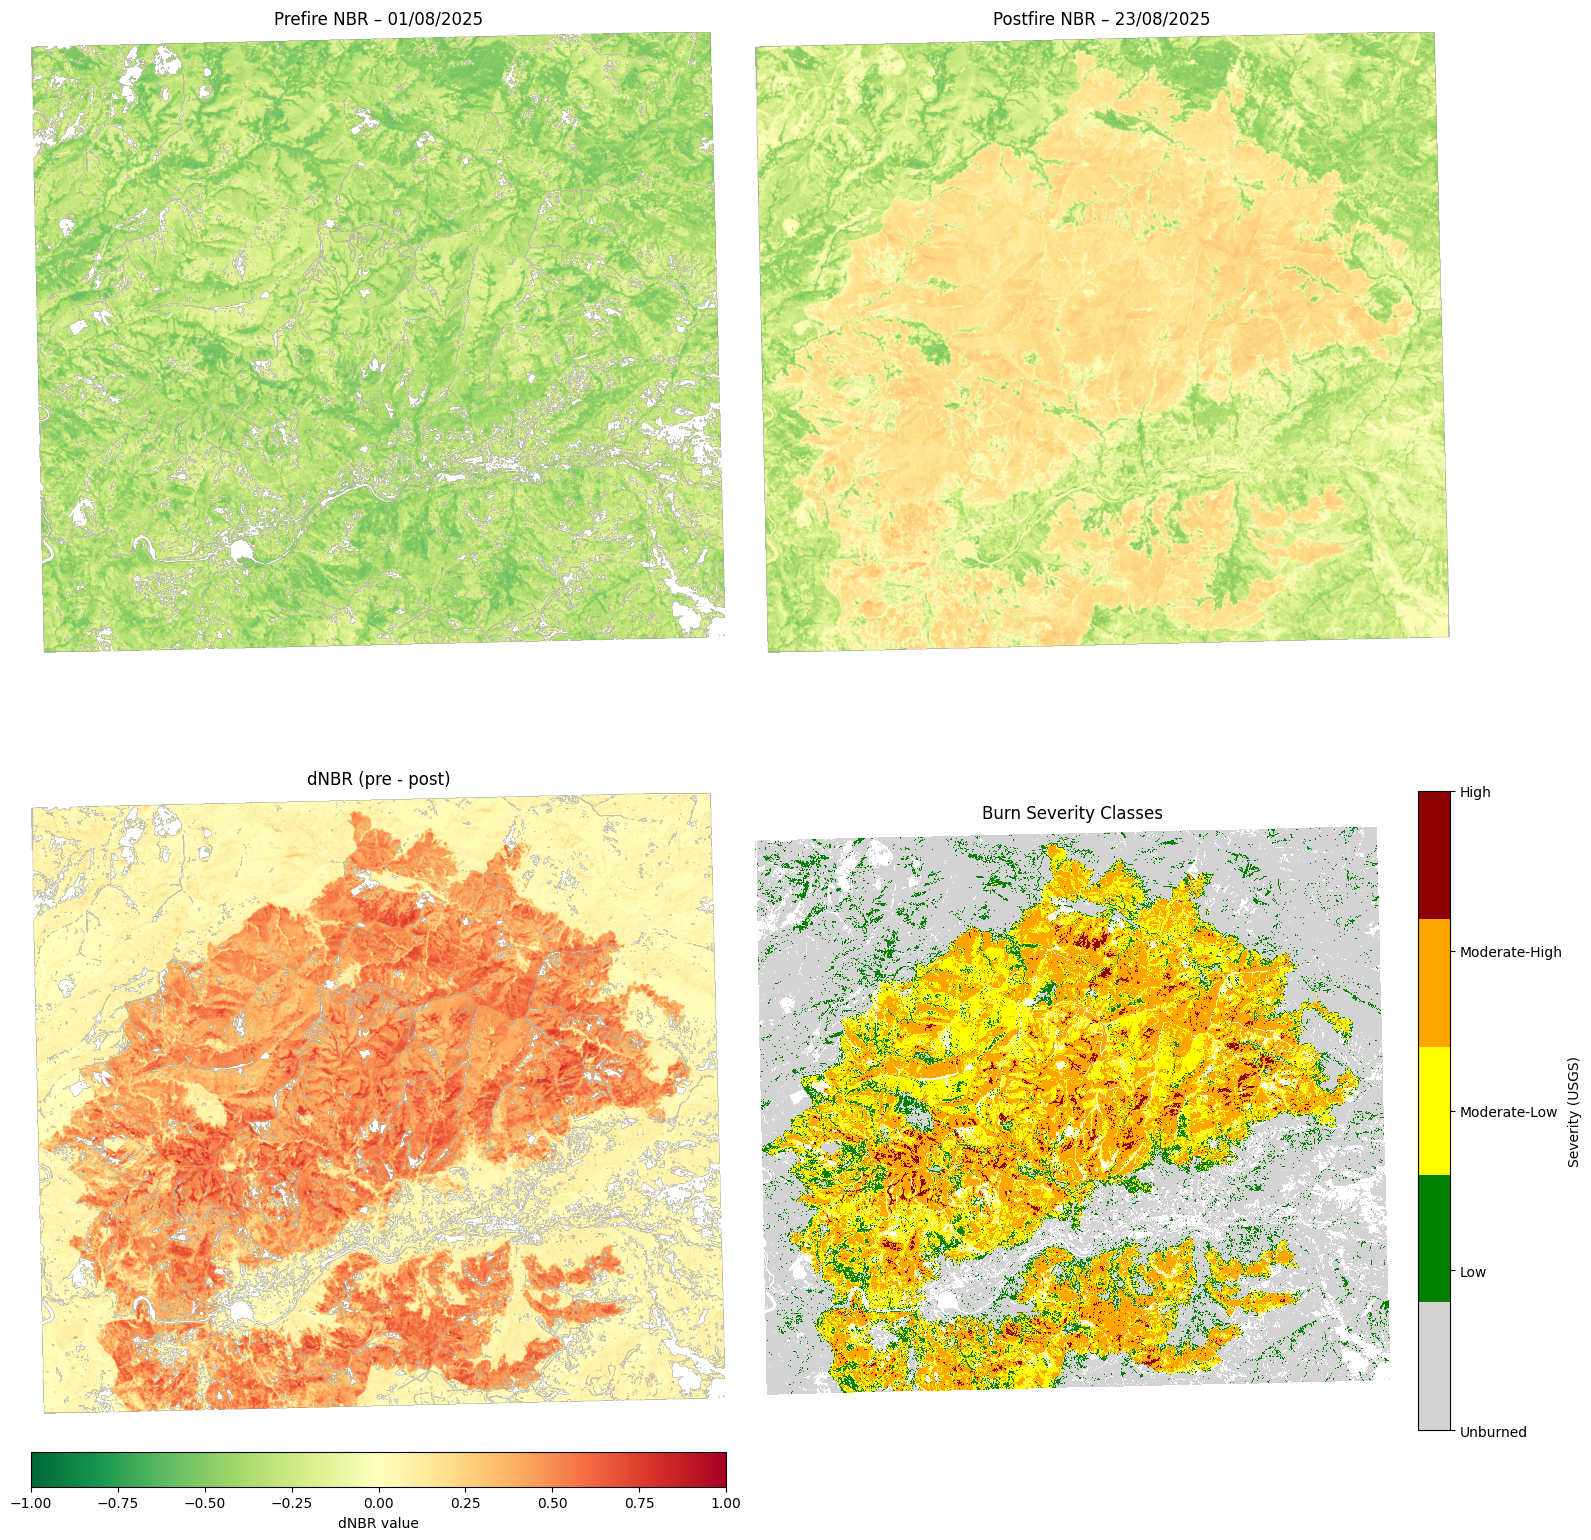

In [41]:
nodata = -9999.0

#5. Create masked arrays for plotting
nbr_pre_masked = ma.masked_equal(nbr_pre, nodata).squeeze()
nbr_post_masked = ma.masked_equal(nbr_post, nodata).squeeze()
dnbr_masked = ma.masked_equal(dnbr, nodata).squeeze()
severity_masked = ma.masked_equal(severity, 255).squeeze()

# 6. Define colormap
severity_cmap = ListedColormap(['lightgray', 'green', 'yellow', 'orange', 'darkred'])
severity_labels = ['Unburned', 'Low', 'Moderate-Low', 'Moderate-High', 'High']

# 7. Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

# Prefire NBR
axes[0,0].imshow(nbr_pre_masked, cmap='RdYlGn', vmin=-1, vmax=1)
axes[0,0].set_title("Prefire NBR – 01/08/2025")
axes[0,0].axis('off')

# Postfire NBR
axes[0,1].imshow(nbr_post_masked, cmap='RdYlGn', vmin=-1, vmax=1)
axes[0,1].set_title("Postfire NBR – 23/08/2025")
axes[0,1].axis('off')

# dNBR
im_dnbr = axes[1,0].imshow(dnbr_masked, cmap='RdYlGn_r', vmin=-1, vmax=1)
axes[1,0].set_title("dNBR (pre - post)")
axes[1,0].axis('off')

# Severity classes
im_sev = axes[1,1].imshow(severity_masked, cmap=severity_cmap, vmin=0, vmax=4, interpolation='nearest')
axes[1,1].set_title("Burn Severity Classes")
axes[1,1].axis('off')

# Colorbars
cbar_dnbr = fig.colorbar(im_dnbr, ax=axes[1,0], orientation='horizontal', fraction=0.05, pad=0.05)
cbar_dnbr.set_label('dNBR value')

cbar_sev = fig.colorbar(im_sev, ax=axes[1,1], ticks=range(5), fraction=0.046, pad=0.04)
cbar_sev.set_ticklabels(severity_labels)
cbar_sev.set_label('Severity (USGS)')

plt.tight_layout()
plt.show()

## Validation

**1. Create burn polygon**

In [92]:
def create_burn_scar_polygon(dnbr_path, threshold, min_area_ha, output_path=None):
    """
    Convert dNBR raster to binary burn scar polygon
    
    Parameters:
        dnbr_path: Path to dNBR raster
        threshold: dNBR threshold for burned (default 0.1 = USGS "low severity" minimun)
        min_area_ha: Minimum patch size to keep (removes noise)
        output_path: Where to save the polygon (optional)
    
    Returns:
        Geodataframe with burn scar polygon(s)
    """

    #1. Load dNBR
    with rasterio.open(dnbr_path) as src:
        dnbr = src.read(1)
        transform = src.transform
        crs = src.crs
        nodata = 255

    
    #2. Create binary burn mask (burned = 1, unburned = 0)
    burn_mask = np.zeros_like(dnbr, dtype='uint8')

    # Only classify valid pixels (not nodata)
    valid_mask = (dnbr != nodata)
    burn_mask[valid_mask & (dnbr >= threshold)] = 1

    burned_pixels = np.sum(burn_mask == 1)
    total_valid = np.sum(valid_mask)

    print(f"\nThreshold: dNBR >= {threshold}")
    print(f" Burned pixels: {burned_pixels:,} ({burned_pixels / total_valid*100:.2f}% of valid area)")

    #Fill small holes inside burned areas
    burn_mask_filled = binary_fill_holes(burn_mask)

    #Close small gaps (connects nearby burned pixels)
    #Adjust iterations based on your pixel size (higher = more aggresive smoothing)
    structure = np.ones((1, 1)) #3x3 kernel
    burn_mask_closed = binary_closing(burn_mask_filled, structure=structure)

    #Convert back to uint8 for rasterio.features.shapes()
    burn_mask_closed = burn_mask_closed.astype('uint8')

    burn_pixels_after = np.sum(burn_mask_closed == 1)
    print(f"Burned pixels (after morphology): {burn_pixels_after:,} ({burn_pixels_after / total_valid*100:.2f}%)")
    
    #3. Convert to polygons

    records = []

    for geom, value in shapes(
        burn_mask_closed,
        mask=(burn_mask_closed == 1), #Only extract burned pixels
        transform=transform
    ):
        records.append({
            'geometry': shape(geom),
            'burned': int(value)
        })

    if not records:
        print("Error: No burned areas detected above threshold")
        return None
    
    gdf = gpd.GeoDataFrame(records, crs=crs)

    #4. Calculate areas and filter small patches
    pixel_area_m2 = abs(transform[0]*transform[4])
    gdf['area_m2'] = gdf.geometry.area
    gdf['area_ha'] = gdf['area_m2'] / 10_000

    print(f"\nInitial polygons: {len(gdf)}")
    print(f" Total area: {gdf['area_ha'].sum():.2f} ha")

    #Filter small patches (noice)
    gdf_filtered = gdf[gdf['area_ha'] >= min_area_ha].copy()

    removed = len(gdf) - len(gdf_filtered)
    if removed > 0:
        print(f"Removed {removed} small patches (< {min_area_ha} ha)")

    #5. Merge all geometries
    merged_geom = unary_union(gdf_filtered.geometry)

    #Create final GeoDataFrame

    gdf_dissolved = gpd.GeoDataFrame(
        {
            'burned': [1],
            'area_m2': [merged_geom.area],
            'area_ha': [merged_geom.area / 10_000],
            'area_km2': [merged_geom.area / 1_000_000],
            'perimeter_m': [merged_geom.length],
            'perimeter_km': [merged_geom.length / 1000],
            'n_patches': [len(gdf_filtered)],
            'dnbr_threshold': [threshold]
        },
        geometry=[merged_geom],
        crs=crs
    )

    print(f"\nFinal burn scar:")
    print(f" Area: {gdf_dissolved['area_ha'].iloc[0]:.2f} ha ({gdf_dissolved['area_km2'].iloc[0]:.2f} km2)")
    print(f" Number of patches: {gdf_dissolved['n_patches'].iloc[0]}")

    #Save as geopackage
    if output_path:
        gdf_dissolved.to_file(output_path, driver="GPKG")
        print(f"\nSaved to: {output_path}")

    return gdf_dissolved

In [96]:
burn = create_burn_scar_polygon(
    DNBR_PATH,
    threshold=0.3,
    min_area_ha=0.1,
    output_path=POLYGON_PATH
)


Threshold: dNBR >= 0.3
 Burned pixels: 731,934 (39.49% of valid area)
Burned pixels (after morphology): 835,542 (45.08%)

Initial polygons: 1159
 Total area: 33421.68 ha
Removed 684 small patches (< 0.1 ha)

Final burn scar:
 Area: 33387.36 ha (333.87 km2)
 Number of patches: 475

Saved to: c:\Repos\ARua_Wildfire\output\with_qa\burn_polygons_with_qa.gpkg


In [97]:
import numpy as np
import geopandas as gpd
from shapely.geometry import shape
from shapely.ops import unary_union
from scipy.ndimage import binary_fill_holes, binary_closing
import rasterio
from rasterio.features import shapes


def create_burn_scar_polygon(dnbr_path, threshold, min_area_ha, output_path=None, dissolve=False):
    """
    Convert dNBR raster to burn scar polygon(s)
    
    Parameters:
        dnbr_path: Path to dNBR raster
        threshold: dNBR threshold for burned (default 0.1 = USGS "low severity" minimum)
        min_area_ha: Minimum patch size to keep (removes noise)
        output_path: Where to save the polygon (optional)
        dissolve: If True, merge all patches into single polygon. If False, keep separate. (NEW!)
    
    Returns:
        GeoDataFrame with burn scar polygon(s)
    """

    # 1. Load dNBR
    with rasterio.open(dnbr_path) as src:
        dnbr = src.read(1)
        transform = src.transform
        crs = src.crs
        nodata = 255

    # 2. Create binary burn mask (burned = 1, unburned = 0)
    burn_mask = np.zeros_like(dnbr, dtype='uint8')

    # Only classify valid pixels (not nodata)
    valid_mask = (dnbr != nodata)
    burn_mask[valid_mask & (dnbr >= threshold)] = 1

    burned_pixels = np.sum(burn_mask == 1)
    total_valid = np.sum(valid_mask)

    print(f"\nThreshold: dNBR >= {threshold}")
    print(f"Burned pixels: {burned_pixels:,} ({burned_pixels / total_valid*100:.2f}% of valid area)")

    # Fill small holes inside burned areas
    burn_mask_filled = binary_fill_holes(burn_mask)

    # Close small gaps (connects nearby burned pixels)
    # Adjust iterations based on your pixel size (higher = more aggressive smoothing)
    structure = np.ones((1, 1))  # 3x3 kernel - CHANGE TO (1, 1) FOR NO SMOOTHING
    burn_mask_closed = binary_closing(burn_mask_filled, structure=structure)

    # Convert back to uint8 for rasterio.features.shapes()
    burn_mask_closed = burn_mask_closed.astype('uint8')

    burn_pixels_after = np.sum(burn_mask_closed == 1)
    print(f"Burned pixels (after morphology): {burn_pixels_after:,} ({burn_pixels_after / total_valid*100:.2f}%)")
    
    # 3. Convert to polygons
    records = []

    for geom, value in shapes(
        burn_mask_closed,
        mask=(burn_mask_closed == 1),  # Only extract burned pixels
        transform=transform
    ):
        records.append({
            'geometry': shape(geom),
            'burned': int(value)
        })

    if not records:
        print("Error: No burned areas detected above threshold")
        return None
    
    gdf = gpd.GeoDataFrame(records, crs=crs)

    # 4. Calculate areas and filter small patches
    pixel_area_m2 = abs(transform[0]*transform[4])
    gdf['area_m2'] = gdf.geometry.area
    gdf['area_ha'] = gdf['area_m2'] / 10_000

    print(f"\nInitial polygons: {len(gdf)}")
    print(f"Total area: {gdf['area_ha'].sum():.2f} ha")

    # Filter small patches (noise)
    gdf_filtered = gdf[gdf['area_ha'] >= min_area_ha].copy()

    removed = len(gdf) - len(gdf_filtered)
    if removed > 0:
        print(f"Removed {removed} small patches (< {min_area_ha} ha)")

    # 5. CONDITIONAL DISSOLUTION (NEW!)
    if dissolve:
        print("\n⚠ DISSOLVING all patches into single polygon...")
        
        # Merge all geometries
        merged_geom = unary_union(gdf_filtered.geometry)

        # Create final GeoDataFrame
        gdf_final = gpd.GeoDataFrame(
            {
                'burned': [1],
                'area_m2': [merged_geom.area],
                'area_ha': [merged_geom.area / 10_000],
                'area_km2': [merged_geom.area / 1_000_000],
                'perimeter_m': [merged_geom.length],
                'perimeter_km': [merged_geom.length / 1000],
                'n_patches': [len(gdf_filtered)],
                'dnbr_threshold': [threshold]
            },
            geometry=[merged_geom],
            crs=crs
        )

        print(f"\nFinal burn scar (DISSOLVED):")
        print(f" Area: {gdf_final['area_ha'].iloc[0]:.2f} ha ({gdf_final['area_km2'].iloc[0]:.2f} km2)")
        print(f" Perimeter: {gdf_final['perimeter_km'].iloc[0]:.2f} km")
        print(f" Number of patches (pre-dissolution): {gdf_final['n_patches'].iloc[0]}")
        
    else:
        print("\n✓ KEEPING individual patches (no dissolution)...")
        
        # Add perimeter info to each patch
        gdf_filtered['area_km2'] = gdf_filtered['area_m2'] / 1_000_000
        gdf_filtered['perimeter_m'] = gdf_filtered.geometry.length
        gdf_filtered['perimeter_km'] = gdf_filtered['perimeter_m'] / 1000
        gdf_filtered['dnbr_threshold'] = threshold
        
        # Calculate total metrics
        total_area_ha = gdf_filtered['area_ha'].sum()
        total_area_km2 = gdf_filtered['area_km2'].sum()
        total_perimeter_km = gdf_filtered['perimeter_km'].sum()
        
        print(f"\nFinal burn scar (SEPARATE PATCHES):")
        print(f" Number of patches: {len(gdf_filtered)}")
        print(f" Total area: {total_area_ha:.2f} ha ({total_area_km2:.2f} km2)")
        print(f" Total perimeter: {total_perimeter_km:.2f} km")
        print(f" Mean patch size: {gdf_filtered['area_ha'].mean():.2f} ha")
        print(f" Largest patch: {gdf_filtered['area_ha'].max():.2f} ha")
        print(f" Smallest patch: {gdf_filtered['area_ha'].min():.2f} ha")
        
        gdf_final = gdf_filtered

    # Save as geopackage
    if output_path:
        gdf_final.to_file(output_path, driver="GPKG")
        print(f"\n✓ Saved to: {output_path}")

    return gdf_final


# =============================================================================
# USAGE EXAMPLES
# =============================================================================

"""
# OPTION 1: Keep individual patches (recommended for ground truth comparison)
burn = create_burn_scar_polygon(
    DNBR_PATH,
    threshold=0.1,
    min_area_ha=5.0,      # Increased from 1.0
    dissolve=False,       # NEW! Keep patches separate
    output_path=POLYGON_PATH
)

# OPTION 2: Dissolve into single polygon (old behavior)
burn = create_burn_scar_polygon(
    DNBR_PATH,
    threshold=0.1,
    min_area_ha=5.0,
    dissolve=True,        # NEW! Merge all patches
    output_path=POLYGON_PATH
)

# OPTION 3: Even more conservative filtering
burn = create_burn_scar_polygon(
    DNBR_PATH,
    threshold=0.27,       # Moderate+ severity only
    min_area_ha=10.0,     # Larger minimum patch
    dissolve=False,
    output_path=POLYGON_PATH
)
"""

# =============================================================================
# EXPECTED RESULTS WITH dissolve=False
# =============================================================================

"""
If your ground truth has 454 patches, you should now get:

Predicted: ~300-500 features (instead of 1)
Reference: 454 features

Perimeter Comparison:
Reference perimeter:   2,814 km
Predicted perimeter:   ~2,500-3,000 km  (much closer!)
Difference:            ~-10% to +10%    (instead of -83%)

Shape metrics:
Reference compactness:  0.0005
Predicted compactness:  ~0.0005-0.001   (similar fragmentation)

IoU should stay high (88%+) while perimeter match improves dramatically!
"""

# =============================================================================
# ADDITIONAL RECOMMENDATIONS
# =============================================================================

"""
1. Try dissolve=False first
   - See if perimeter matches better
   - Check if number of patches is reasonable

2. If you have TOO MANY patches (e.g., 1000+):
   - Increase min_area_ha to 5.0 or 10.0
   - This removes tiny noise patches

3. If you have TOO FEW patches (e.g., 50):
   - Decrease min_area_ha to 2.0 or 3.0
   - Lower threshold to 0.08 or 0.05

4. For morphological smoothing:
   - Keep structure = np.ones((3, 3)) for moderate smoothing
   - Use structure = np.ones((1, 1)) for minimal smoothing (what you tested)
   - Use structure = np.ones((5, 5)) for aggressive smoothing

5. The goal is to match ground truth in:
   ✓ Number of patches (within 20-30%)
   ✓ Perimeter (within ±15%)
   ✓ Area (you're already close!)
   ✓ Compactness (similar fragmentation)
"""

"\n1. Try dissolve=False first\n   - See if perimeter matches better\n   - Check if number of patches is reasonable\n\n2. If you have TOO MANY patches (e.g., 1000+):\n   - Increase min_area_ha to 5.0 or 10.0\n   - This removes tiny noise patches\n\n3. If you have TOO FEW patches (e.g., 50):\n   - Decrease min_area_ha to 2.0 or 3.0\n   - Lower threshold to 0.08 or 0.05\n\n4. For morphological smoothing:\n   - Keep structure = np.ones((3, 3)) for moderate smoothing\n   - Use structure = np.ones((1, 1)) for minimal smoothing (what you tested)\n   - Use structure = np.ones((5, 5)) for aggressive smoothing\n\n5. The goal is to match ground truth in:\n   ✓ Number of patches (within 20-30%)\n   ✓ Perimeter (within ±15%)\n   ✓ Area (you're already close!)\n   ✓ Compactness (similar fragmentation)\n"

In [98]:
burn = create_burn_scar_polygon(
    DNBR_PATH,
    threshold=0.3,
    min_area_ha=0.1,
    output_path=POLYGON_PATH,
    dissolve=False
)


Threshold: dNBR >= 0.3
Burned pixels: 731,934 (39.49% of valid area)
Burned pixels (after morphology): 835,542 (45.08%)

Initial polygons: 1159
Total area: 33421.68 ha
Removed 684 small patches (< 0.1 ha)

✓ KEEPING individual patches (no dissolution)...

Final burn scar (SEPARATE PATCHES):
 Number of patches: 475
 Total area: 33387.36 ha (333.87 km2)
 Total perimeter: 1041.24 km
 Mean patch size: 70.29 ha
 Largest patch: 26467.52 ha
 Smallest patch: 0.12 ha

✓ Saved to: c:\Repos\ARua_Wildfire\output\with_qa\burn_polygons_with_qa.gpkg


In [99]:
def create_burn_polygons_from_severity(severity_path, output_path, min_area_ha=0.5, min_severity=1):
    """
    Adapted from create_burn_polygons, but uses severity map instead of dNBR.
    - Threshold: severity >= min_severity (e.g., 1 for all burned, 2 for moderate+).
    - Generates one set of polygons for the combined burned area.
    - For per-class polygons, see optional extension below.
    """
    with rasterio.open(severity_path) as src:
        severity = src.read(1).astype(np.float32)
        meta = src.meta.copy()
        transform = src.transform
        crs = src.crs
    
    # Binary mask: burned where severity >= min_severity
    burned_mask = (severity >= min_severity) & (severity != 255)  # Exclude nodata if any
    
    # Morphological cleaning (same as original)
    burned_mask = binary_closing(burned_mask, iterations=2)
    burned_mask = binary_opening(burned_mask, iterations=1)
    burned_mask = binary_fill_holes(burned_mask)
    
    # Label connected components
    labeled, num_features = label(burned_mask)
    print(f"Detected {num_features} initial burn features")
    
    # Vectorize with area filtering
    pixel_area_m2 = abs(transform.a * transform.e)  # Pixel area in m²
    min_area_m2 = min_area_ha * 10_000
    
    shapes_gen = shapes(labeled.astype(np.int32), transform=transform)
    
    polygons = []
    for geom, label_val in shapes_gen:
        if label_val == 0:  # Background
            continue
        
        poly = shape(geom)
        area_m2 = poly.area
        
        if area_m2 < min_area_m2:
            continue
        
        polygons.append({
            'geometry': poly,
            'properties': {
                'id': int(label_val),
                'area_ha': area_m2 / 10_000
            }
        })
    
    if not polygons:
        print("No burn polygons found after filtering.")
        return None
    
    gdf = gpd.GeoDataFrame.from_features(polygons, crs=crs)
    gdf = gdf.sort_values('area_ha', ascending=False).reset_index(drop=True)
    
    gdf.to_file(output_path, driver='GPKG')
    print(f"Saved {len(gdf)} burn polygons to {output_path}")
    
    return gdf

In [100]:
burn = create_burn_polygons_from_severity(
    DNBR_PATH,
    POLYGON_PATH,
    min_area_ha=0.5,
    min_severity=1,
)

Detected 0 initial burn features
No burn polygons found after filtering.


**2. Compare dnbr perimeter with ground truth (Copernicus EMS (EMSR837))**

In [101]:
def compare_burn_scars(predicted_polygon_path, reference_polygon_path, output_dir):
    """
    Compare predicted burn scar with reference (Copernicus EMS observed event)

    Parameters:
        predicted_polygon_path: dNBR-derived burn scar
        reference_polygon_path: Copernicus EMS
        output_dir: Where to save comparison outputs

    Returns:
        Dictionary with comparison metrics
    """

    #1. Load polygons
    predicted_gdf = gpd.read_file(predicted_polygon_path)
    reference_gdf = gpd.read_file(reference_polygon_path)

    print(f"\nPredicted: {len(predicted_gdf)} features")
    print(f"Reference: {len(reference_gdf)} features")

    #2. Reprojected if needed
    if predicted_gdf.crs != reference_gdf.crs:
        print(f" \nReprojecting reference from {reference_gdf.crs} to {predicted_gdf.crs}")

    #3. Dissolve to single geometry
    predicted_geom = unary_union(predicted_gdf.geometry)
    reference_geom = unary_union(reference_gdf.geometry)

    #4.Calculate basic metrics
    pred_area = predicted_geom.area
    ref_area = reference_geom.area
    pred_perimeter = predicted_geom.length
    ref_perimeter = reference_geom.length

    print("Area Comparison")
    print(f"Reference area: {ref_area/10_000:>10,.2f} ha ({ref_area/1_000_000:>8,.2f} km2)")
    print(f"Predicted area: {pred_area/10_000:>10,.2f} ha ({pred_area/1_000_000:>8,.2f} km2)")
    area_diff = pred_area - ref_area
    area_diff_pct = (area_diff / ref_area) * 100

    print(f"Difference: {area_diff/10_000:>+10,.2f} ha ({area_diff_pct:>+8,.2f}%)")

    print("Perimeter Comparison")
    print(f"Reference perimeter: {ref_perimeter/1000:>10,.2f} km")
    print(f"Predicted perimeter: {pred_perimeter/1000:>10,.2f} km")

    perim_diff = pred_perimeter - ref_perimeter
    perim_diff_pct = (perim_diff / ref_perimeter) * 100

    print(f"Difference: {perim_diff/1000:>+10,.2f} km ({perim_diff_pct:>+8,.2f})")

    #5. Spatial overlap metrics

    print("Spatial overlap metrics")
    #Intersection (area correctly identified as burned)
    intersection = predicted_geom.intersection(reference_geom)
    intersection_area = intersection.area

    #Union (total burned area in either dataset)
    union = predicted_geom.union(reference_geom)
    union_area = union.area

    #Difference (errors)
    false_positive = predicted_geom.difference(reference_geom)
    false_negative = reference_geom.difference(predicted_geom)

    fp_area = false_positive.area
    fn_area = false_negative.area

    #Calculate accuracy metrics
    iou = intersection_area / union_area # Jaccard Index / Intersection over Union
    dice = (2 * intersection_area) / (pred_area + ref_area) # Dice / F1
    precision = intersection_area / pred_area if pred_area > 0 else 0
    recall = intersection_area / ref_area if ref_area > 0 else 0

    print(f"Intersection (correct): {intersection_area/10_000:>10,.2f} ha")
    print(f"Union (total):          {union_area/10_000:>10,.2f} ha")
    print(f"False Positive (over):  {fp_area/10_000:>10,.2f} ha ({fp_area/ref_area*100:>6,.2f}% of ref)")
    print(f"False Negative (under): {fn_area/10_000:>10,.2f} ha ({fn_area/ref_area*100:>6,.2f}% of ref)")
    print()
    print(f"IoU (Jaccard Index):    {iou:>10.4f} ({iou*100:>6.2f}%)")
    print(f"Dice Coefficient (F1):  {dice:>10.4f} ({dice*100:>6.2f}%)")
    print(f"Precision:              {precision:>10.4f} ({precision*100:>6.2f}%)")
    print(f"Recall:                 {recall:>10.4f} ({recall*100:6.2f}%)")


    #6. Shape metrics (compactness)

    #Compactness = area / perimeter^2 (normalized, 1.0 = perfect circle)
    print("Shape metrics")
    pred_compact = (4 * np.pi * pred_area) / (pred_perimeter ** 2)
    ref_compact = (4 * np.pi * ref_area) / (ref_perimeter ** 2)

    print(f"Reference compactness:  {ref_compact:.4f}")
    print(f"Predicted compactness:  {pred_compact:.4f}")
    print(f"(1.0 = perfect circle, lower = more irregular/fragmented)")

    #7. Save outputs if requested
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)

        #Save difference geometries
        error_gdf = gpd.GeoDataFrame(
            {
                'error_type': ['False Positive (over-mapped)', 'False Negative (under-mapped)'],
                'area_ha': [fp_area/10_000, fn_area/10_000],
                'area_pct': [fp_area/ref_area*100, fn_area/ref_area*100]
            },
            geometry=[false_positive, false_negative],
            crs=predicted_gdf.crs
        )

        error_path = os.path.join(output_dir, "burn_scar_errors.gpkg")
        error_gdf.to_file(error_path, driver='GPKG')
        print(f"\nSaved error polygons to: {error_path}")

        #Save metrics to CSV

        metrics = {
            'Metric': [
                'Reference Area (ha)', 'Predicted Area (ha)', 'Area Difference (ha)', 'Area Difference (%)',
                'Reference Perimeter (km)', 'Predicted Perimeter (km)', 'Perimeter Difference (%)', 'Perimeter_Difference (%)',
                'Intersection (ha)', 'Union (ha)', 'False Positive (ha)', 'False_Negative (ha)',
                'IoU', 'Dice/F1', 'Precision', 'Recall',
                'Reference Compactness', 'Predicted Compacteness'
            ],
            'Value': [
                ref_area/10_000, pred_area/10_000, area_diff/10_000, area_diff_pct,
                ref_perimeter/1000, pred_perimeter/1000, perim_diff/1000, perim_diff_pct,
                intersection_area/10_000, union_area/10_000, fp_area/10_000, fn_area/10_000,
                iou, dice, precision, recall,
                ref_compact, pred_compact
            ]
        }

        metrics_df = pd.DataFrame(metrics)
        metrics_path = os.path.join(output_dir, 'comparison_metrics.csv')
        metrics_df.to_csv(metrics_path, index=False)
        print(f"Saved metrics to: {metrics_path}")

        #8. Return results

        results = {
            'predicted_geom': predicted_geom,
            'reference_geom': reference_geom,
            'intersection': intersection,
            'false_positive': false_positive,
            'false_negative': false_negative,
            'metrics': {
                'area_pred_ha': pred_area/10_000,
                'area_ref_ha': ref_area/10_000,
                'area_diff_pct': area_diff_pct,
                'perimeter_pred_km': pred_perimeter/1000,
                'perimeter_ref_km': ref_perimeter/10_000,
                'perimeter_diff_pct': perim_diff_pct,
                'iou': iou,
                'dice': dice,
                'precision': precision,
                'recall': recall,
                'false_positive_ha': fp_area/10_000,
                'false_negative_ha': fn_area/10_000
            }
        }
        
        return results

In [102]:
compare = compare_burn_scars(
    POLYGON_PATH,
    FIRE_PATH,
    OUTPUT_DIR
)


Predicted: 475 features
Reference: 454 features
Area Comparison
Reference area:  33,002.94 ha (  330.03 km2)
Predicted area:  33,387.36 ha (  333.87 km2)
Difference:    +384.42 ha (   +1.16%)
Perimeter Comparison
Reference perimeter:   2,814.11 km
Predicted perimeter:   1,041.24 km
Difference:  -1,772.87 km (  -63.00)
Spatial overlap metrics
Intersection (correct):  31,356.54 ha
Union (total):           35,033.76 ha
False Positive (over):    2,030.82 ha (  6.15% of ref)
False Negative (under):   1,646.40 ha (  4.99% of ref)

IoU (Jaccard Index):        0.8950 ( 89.50%)
Dice Coefficient (F1):      0.9446 ( 94.46%)
Precision:                  0.9392 ( 93.92%)
Recall:                     0.9501 ( 95.01%)
Shape metrics
Reference compactness:  0.0005
Predicted compactness:  0.0039
(1.0 = perfect circle, lower = more irregular/fragmented)

Saved error polygons to: c:\Repos\ARua_Wildfire\output\with_qa\burn_scar_errors.gpkg
Saved metrics to: c:\Repos\ARua_Wildfire\output\with_qa\comparison_m

**3. Severity Assessment**

In [103]:
def severity_area(predicted_polygon_path, severity_path, severity_labels=None):

    if severity_labels is None:
    # Define labels **inside** the function (or pass as argument / import from config)
        severity_labels = {
            0: "Unburned",
            1: "Low",
            2: "Moderate-Low",
            3: "Moderate-High",
            4: "High"
        }
    
# 1. Load predicted burn polygons and merge them
    predicted_gdf = gpd.read_file(predicted_polygon_path)
    # Optional: check/fix CRS match
    if predicted_gdf.crs != "EPSG:32629":
        predicted_gdf = predicted_gdf.to_crs("EPSG:32629")
    
    predicted_geom = unary_union(predicted_gdf.geometry)
    # Make sure it's a list of geometries for rasterio.mask
    shapes_geom = [predicted_geom.__geo_interface__] if predicted_geom.geom_type != "GeometryCollection" else \
                  [g.__geo_interface__ for g in predicted_geom.geoms]

# 2. Load severity raster and extract only inside predicted area
    with rasterio.open(severity_path) as src:
        severity_meta = src.meta.copy()
        severity_data, transform = mask(
            src,
            shapes_geom,
            crop=True,
            nodata=255,           # use a value outside 0–4
            filled=False          # keep as masked array
        )
        severity = severity_data[0]  # single band
        severity_meta.update({
            "driver": "GTiff",
            "height": severity.shape[0],
            "width": severity.shape[1],
            "transform": transform
        })

# 3. Remove masked pixels:
    severity_flat = severity[~severity.mask]  # remove masked pixels
    if severity_flat.size == 0:
        print("No valid pixels inside predicted area.")
        return None, None

    # Count pixels per class
    unique, counts = np.unique(severity_flat, return_counts=True)

    # Pixel area in hectares
    pixel_area_ha = abs(severity_meta["transform"].a * severity_meta["transform"].e) / 10_000

    # Build table
    area_table = []
    for val, cnt in zip(unique, counts):
        if val not in severity_labels:  # skip unexpected values
            continue
        area_ha = cnt * pixel_area_ha
        area_table.append({
            "severity": int(val),
            "severity_label": severity_labels.get(int(val), "Other"),
            "area_ha": area_ha
        })

    area_table = gpd.GeoDataFrame(area_table).sort_values("severity")
    
    print(area_table)

In [104]:
burn_severity_area = severity_area(
    POLYGON_PATH,
    SEVERITY_PATH,
)

   severity severity_label   area_ha
0         0       Unburned    304.08
1         1            Low   1521.72
2         2   Moderate-Low  12790.96
3         3  Moderate-High  16116.52
4         4           High   1247.36


In [106]:
def severity_landcover_stats(
        predicted_polygon_path, 
        severity_path, 
        landcover_path, 
        severity_labels=None,
        landcover_class_col: str = "info"):
    
    if severity_labels is None:
        severity_labels = {
            0: "Unburned", 1: "Low", 2: "Moderate-Low",
            3: "Moderate-High", 4: "High"
        }
    
    # 1. Load predicted burn area (merge to one geometry)
    predicted_gdf = gpd.read_file(predicted_polygon_path)
    if predicted_gdf.crs != "EPSG:32629":
        predicted_gdf = predicted_gdf.to_crs("EPSG:32629")
    predicted_geom = unary_union(predicted_gdf.geometry)
    burn_shapes = [predicted_geom.__geo_interface__]
    
    # 2. Load & mask severity raster to burn area
    with rasterio.open(severity_path) as src_sev:
        sev_meta = src_sev.meta.copy()
        sev_data, sev_transform = mask(
            src_sev, burn_shapes, crop=True, nodata=255, filled=True 
        )
        sev = sev_data[0]  # shape (height, width)
        sev_meta.update({
            "height": sev.shape[0],
            "width": sev.shape[1],
            "transform": sev_transform
        })
    
    # 3. Load land cover GeoJSON and clip to burn area
    lc_gdf = gpd.read_file(landcover_path)
    if lc_gdf.crs != "EPSG:32629":
        lc_gdf = lc_gdf.to_crs("EPSG:32629")
    lc_gdf = lc_gdf[lc_gdf.intersects(predicted_geom)].copy()
    
    if lc_gdf.empty:
        print("No land cover polygons intersect the predicted burn area")
        return None, None, None
    
    # 4. Create numeric mapping for land cover classes
    unique_classes = lc_gdf[landcover_class_col].unique()
    class_to_code = {cls: idx for idx, cls in enumerate(unique_classes, start=1)}
    code_to_class = {idx: cls for cls, idx in class_to_code.items()}
    
    # Add numeric codes to GeoDataFrame
    lc_gdf['lc_code'] = lc_gdf[landcover_class_col].map(class_to_code)
    
    # 5. Rasterize land cover to match severity grid
    lc_shapes = ((geom, code) for geom, code in zip(
        lc_gdf.geometry, lc_gdf['lc_code']
    ))
    
    lc_raster = rasterize(
        lc_shapes,
        out_shape=sev.shape,
        transform=sev_transform,
        fill=255,
        dtype=np.uint16,
        all_touched=False
    )
    
    # 6. Valid pixels: both severity and land cover are valid
    valid_mask = (sev != 255) & (lc_raster != 255)
    sev_valid = sev[valid_mask]
    lc_valid = lc_raster[valid_mask]
    
    if sev_valid.size == 0:
        print("No overlapping valid pixels between severity and land cover.")
        return None, None, None
    
    # 7. Pixel area in ha
    pixel_area_ha = abs(sev_transform.a * sev_transform.e) / 10_000
    
    # 8. Count per severity x landcover combination
    multiplier = 10000
    combined = sev_valid.astype(np.int64) * multiplier + lc_valid.astype(np.int64)
    unique_comb, counts = np.unique(combined, return_counts=True)
    
    # 9. Build detailed table
    results = []
    for comb, cnt in zip(unique_comb, counts):
        sev_code = int(comb // multiplier)
        lc_code = int(comb % multiplier)
        area_ha = cnt * pixel_area_ha
        results.append({
            "severity": sev_code,
            "severity_label": severity_labels.get(sev_code, f"Unknown ({sev_code})"),
            "landcover_code": lc_code,
            "landcover_label": code_to_class.get(lc_code, f"Unknown ({lc_code})"),
            "pixels": int(cnt),
            "area_ha": round(area_ha, 3)
        })
    
    df_detailed = pd.DataFrame(results)
    
    # 10. Create summary by severity
    df_summary = df_detailed.groupby(['severity', 'severity_label']).agg({
        'pixels': 'sum',
        'area_ha': 'sum'
    }).reset_index()

    #11. Top-3 land cover by severity
    top3 = (df_detailed
    .sort_values(['severity_label', 'area_ha'], ascending=[True, False])
    .groupby('severity_label', as_index=False)
    .head(3)
    )
    
    print("\n=== Summary by Severity ===")
    print(df_summary.to_string(index=False))
    print("\n=== Top-3 land cover types by Severity ===")
    print(top3.to_string(index=False))
    
    return df_detailed, df_summary, top3

In [107]:
top_3 = severity_landcover_stats(
    POLYGON_PATH,
    SEVERITY_PATH,
    LANDUSE_PATH
)


=== Summary by Severity ===
 severity severity_label  pixels  area_ha
        0       Unburned     166     6.64
        1            Low   16699   667.96
        2   Moderate-Low  302562 12102.48
        3  Moderate-High  400033 16001.32
        4           High   31147  1245.88

=== Top-3 land cover types by Severity ===
 severity severity_label  landcover_code                                                                            landcover_label  pixels  area_ha
        4           High               1                                                                    322-Moors and heathland   14624   584.96
        4           High               7                                                                    311-Broad-leaved forest    6893   275.72
        4           High               3                                                            324-Transitional woodland shrub    4885   195.40
        1            Low               1                                       